In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from matplotlib.ticker import FormatStrFormatter

sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

--------
# Main

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/main_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 340944 5119 0.014792104327824702
No data 340944 0 0.0
LRG mask 306665 34279 0.10054143789009339
Remove QSO targets 301954 4711 0.015362040011087017
Min depth 294756 7198 0.9761619319498996
333
Bad fibers 274382 20374 0.06912157852596724
274382 274355
274382 274355 27
274355 274355 0
274355


In [4]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.017987643746241185
269420


In [5]:
# Densities from target_densities.ipynb
density = 607.74 * np.sum(mask_quality)/len(mask_quality)
density_north =  607.93 * np.sum(mask_quality)/len(mask_quality)
density_south = 607.64 * np.sum(mask_quality)/len(mask_quality)

In [6]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.0043723554301833565


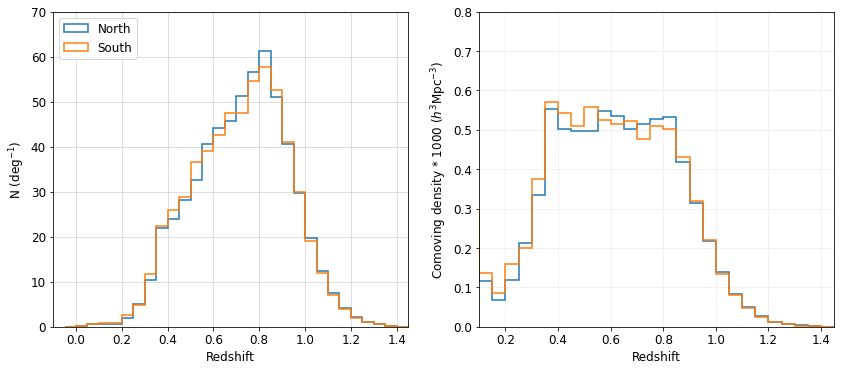

In [7]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

binsize = 0.05
bins = np.arange(-binsize, 1.55, binsize)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-1}$)')
axes[0].set_xlim(-0.1, 1.45)
axes[0].set_ylim(0, 70)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

In [8]:
from astropy.cosmology import FlatLambdaCDM

H0=100
Om0=0.3
cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)

bins_fine = np.arange(-binsize, 1.45, binsize)
shell_volumes = cosmo.comoving_volume(bins[1:]).to_value('Mpc^3')-cosmo.comoving_volume(bins[:-1]).to_value('Mpc^3')
n_plot = 0.5e-3 * shell_volumes / (4*np.pi*(180/np.pi)**2)

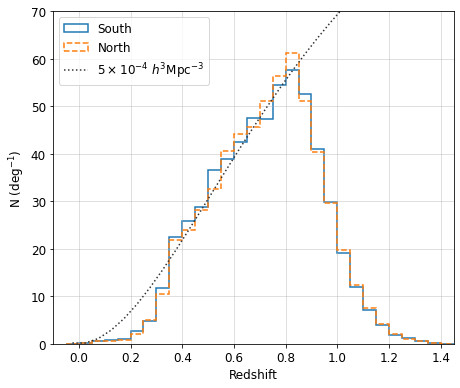

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_main_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C1', ls='--', zorder=2)
nz_main_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C0', zorder=1)
ax.plot(bin_centers, n_plot, '0.2', ls=':', label=r'$5\times10^{-4}\ h^3\mathrm{Mpc}^{-3}$')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-1}$)')
ax.set_xlim(-0.1, 1.45)
ax.set_ylim(0, 70)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_dndz.pdf')
plt.show()

In [10]:
main = cat.copy()

--------
# SV3

In [11]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv3_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]
print(len(cat), len(np.unique(cat['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 164994 17403 0.09541275349923518
No data 164994 0 0.0
LRG mask 151056 13938 0.084475799119968
Remove QSO targets 151056 0 0.0
Min depth 149865 1191 0.9921155068319034
333
Bad fibers 139205 10660 0.07113068428252094
139205 119902
139205 119902 19303
119902 119902 0
119902


In [12]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.013494353722206469
118284


In [13]:
# Densities from target_densities.ipynb
density = 805.83 * np.sum(mask_quality)/len(mask_quality)
density_north =  807.29 * np.sum(mask_quality)/len(mask_quality)
density_south = 805.14 * np.sum(mask_quality)/len(mask_quality)

In [14]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.0019613810828176255


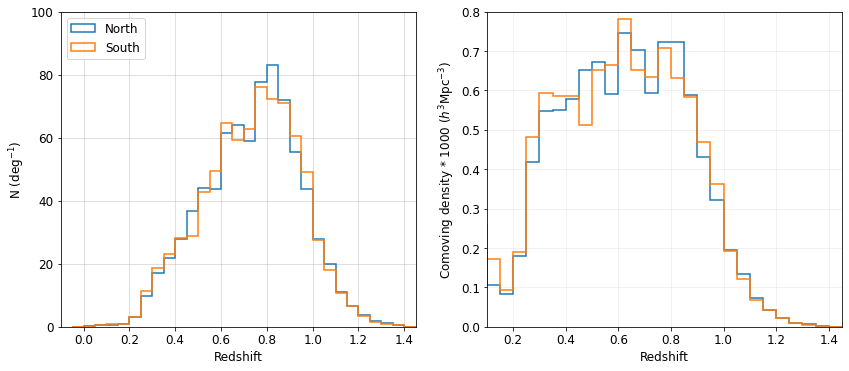

In [15]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

# binsize = 0.05
# bins = np.arange(-binsize, 1.55, binsize)
# bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-1}$)')
axes[0].set_xlim(-0.1, 1.45)
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 0.8], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

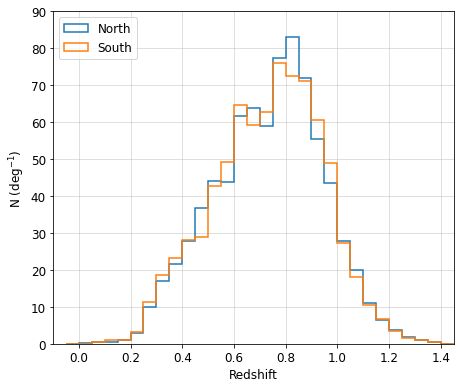

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_sv3_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
nz_sv3_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-1}$)')
ax.set_xlim(-0.1, 1.45)
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/sv3_dndz.pdf')
plt.show()

In [17]:
sv3 = cat.copy()

--------
# SV1

In [18]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/sv1_cumulative_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth
min_depth = 2000.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

# Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-everest.ipynb
# bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/bad_fibers_20211117.txt', dtype=int)
bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', dtype=int)
print(len(bad_fibers))
mask_bad = np.in1d(cat['FIBER'], bad_fibers)
print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
cat = cat[~mask_bad]
print(len(cat), len(np.unique(cat['TARGETID'])))

# ZWARN
mask = cat['ZWARN']==0
print('ZWARN', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

print(len(cat))

FIBERSTATUS 46403 8832 0.15989861500859961
No data 46401 2 4.310066159515549e-05
LRG mask 42199 4202 0.09055839313807892
Remove QSO targets 42199 0 0.0
Min depth 36418 5781 0.8630062323751748
333
Bad fibers 33990 2428 0.06667032785984953
33990 33932
ZWARN 33696 294 0.008649602824360106
33696 33638 58
33638 33638 0
33638


In [19]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)

print(np.sum(~mask_quality)/len(mask_quality))
cat = cat[mask_quality]
print(len(cat))

0.010612997205541352
33281


In [20]:
# Densities from target_densities.ipynb
density = 2124.72 * np.sum(mask_quality)/len(mask_quality)
density_north =  2123.03 * np.sum(mask_quality)/len(mask_quality)
density_south = 2125.53 * np.sum(mask_quality)/len(mask_quality)

In [21]:
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
cat['SPECTYPE'][mask_star] = 'STAR'
print(np.sum(mask_star)/len(mask_star))

0.011207595925603197


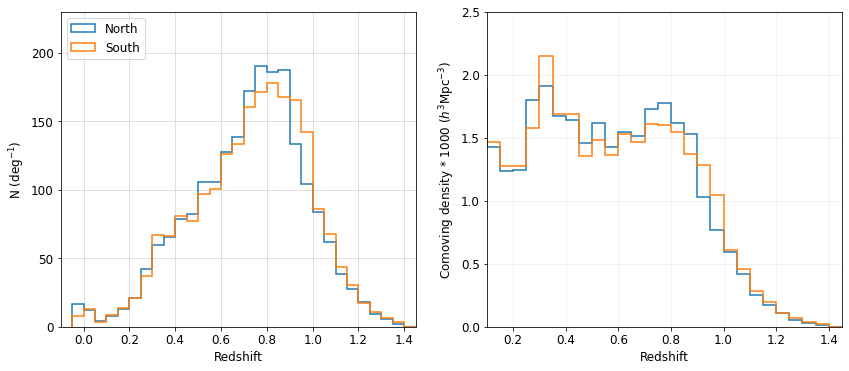

In [22]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

area = len(cat)/density
area_north = np.sum(mask_north)/density_north
area_south = np.sum(mask_south)/density_south

# binsize = 0.05
# bins = np.arange(-binsize, 1.55, binsize)
# bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.ones(int(np.sum(mask_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.ones(int(np.sum(mask_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('N (deg$^{-1}$)')
axes[0].set_xlim(-0.1, 1.45)
axes[0].set_ylim(0, 230)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0., zmax=bins.max(), dz=binsize, axis=[0.1, 1.45, 0, 2.5], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

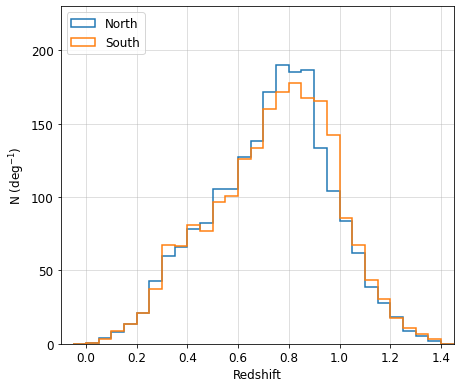

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nz_sv1_north, _, _ = ax.hist(cat['Z'][mask_north & (~mask_star)], weights=np.ones(int(np.sum(mask_north & (~mask_star))))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
nz_sv1_south, _, _ = ax.hist(cat['Z'][mask_south & (~mask_star)], weights=np.ones(int(np.sum(mask_south & (~mask_star))))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-1}$)')
ax.set_xlim(-0.1, 1.45)
ax.set_ylim(0, 230)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/sv1_dndz.pdf')
plt.show()

-------
# N(z) of all LRG samples

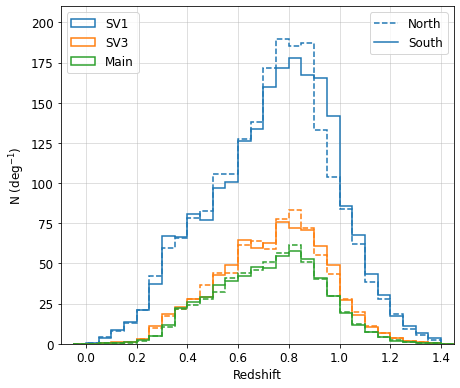

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
_, _, p1 = ax.hist(bin_centers, weights=nz_sv1_south,
             bins=bins, lw=1.5, histtype='step', label='SV1', color='C0')
ax.hist(bin_centers, weights=nz_sv1_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C0', ls='--')
p2 = ax.hist(bin_centers, weights=nz_sv3_south,
             bins=bins, lw=1.5, histtype='step', label='SV3', color='C1')
ax.hist(bin_centers, weights=nz_sv3_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C1', ls='--')
ax.hist(bin_centers, weights=nz_main_south,
             bins=bins, lw=1.5, histtype='step', label='Main', color='C2')
ax.hist(bin_centers, weights=nz_main_north,
             bins=bins, lw=1.5, histtype='step', label=None, color='C2', ls='--')
# ax.plot(bin_centers, n_plot, '0.7', ls='--')
# ax.hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
leg1 = ax.legend(loc='upper left')
p1, = ax.plot([1,2], [-1,-2], ls='-', color='C0')
p2, = ax.plot([1,2], [-1,-2], ls='--', color='C0')
leg2 = ax.legend([p2, p1], ['North', 'South'], loc='upper right')
ax.add_artist(leg1)
# ax.legend([p1, p2, p3], loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('N (deg$^{-1}$)')
ax.set_xlim(-0.1, 1.45)
ax.set_ylim(0, 210)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/all_lrgs_dndz.pdf')
plt.show()

-------

In [25]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [26]:
# fig, ax = plt.subplots(figsize=(16, 6))
# ax.plot(sv1['TARGET_RA'], np.sin(np.radians(sv1['TARGET_DEC'])), '.', ms=0.2, alpha=1, label='SV1', zorder=1)
# ax.plot(sv3['TARGET_RA'], np.sin(np.radians(sv3['TARGET_DEC'])), '.', ms=0.2, alpha=1, label='SV3', zorder=2)
# ax.plot(main['TARGET_RA'], np.sin(np.radians(main['TARGET_DEC'])), '.', color='0.7', ms=.2, alpha=1, label='Main survey', zorder=0)
# ax.set_xlabel('RA (deg)')
# ax.set_ylabel('DEC (deg)')
# ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 20))))
# ax.set_yticklabels(np.arange(-70, 90, 20))
# ax.set_xticks(np.arange(0, 361, 30))
# ax.axis([360, 0, -0.5, 1.])
# ax.grid(alpha=0.5)
# plt.legend(markerscale=30)
# plt.tight_layout()
# # plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/observed_lrgs_radec.png')
# plt.show()

NameError: name 'sv1' is not defined

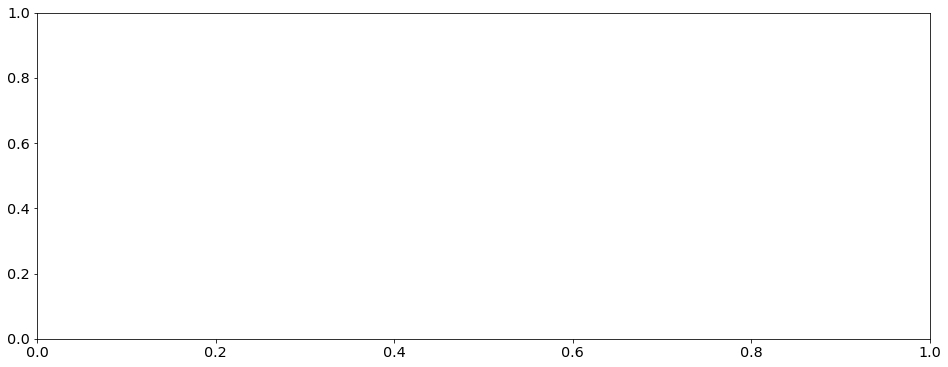

In [27]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(sv1['TARGET_RA'], np.sin(np.radians(sv1['TARGET_DEC'])), 'C0.', ms=0.2, alpha=0.2, zorder=1)
ax.plot(-99, -99, '.', ms=0.2, alpha=1, label='SV1', zorder=1)
ax.plot(sv3['TARGET_RA'], np.sin(np.radians(sv3['TARGET_DEC'])), 'C1.', ms=0.2, alpha=0.2, zorder=2)
ax.plot(-99, -99, '.', ms=0.2, alpha=1, label='SV3', zorder=2)
ax.plot(main['TARGET_RA'], np.sin(np.radians(main['TARGET_DEC'])), '.', color='0.7', ms=.2, alpha=0.2, zorder=0)
ax.plot(-99, -99, '.', color='0.7', ms=.2, alpha=1, label='Main survey', zorder=0)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 20))))
ax.set_yticklabels(np.arange(-70, 90, 20))
ax.set_xticks(np.arange(0, 361, 30))
ax.axis([360, 0, -0.5, 1.])
ax.grid(alpha=0.5)
plt.legend(markerscale=30)
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/observed_lrgs_radec.png')
plt.show()